--- DESCRIPTIVE STATS PER QUESTION ---
                                                    Mean  Std Dev
Algorithmic Serendipity (The pleasant surprise ...  2.98     1.16
Algorithmic Serendipity (The pleasant surprise ...  3.16     1.18
Algorithmic Serendipity (The pleasant surprise ...  2.98     1.20
Algorithmic Serendipity (The pleasant surprise ...  3.15     1.26
Algorithmic Paranoia (Concerns about privacy an...  2.16     0.96
Algorithmic Paranoia (Concerns about privacy an...  2.18     1.03
Algorithmic Paranoia (Concerns about privacy an...  2.12     1.04
Algorithmic Paranoia (Concerns about privacy an...  2.26     1.06
Information Fatigue / Cognitive Overload (Diffi...  2.78     1.19
Information Fatigue / Cognitive Overload (Diffi...  2.93     1.17
Information Fatigue / Cognitive Overload (Diffi...  2.83     1.17
Information Fatigue / Cognitive Overload (Diffi...  2.75     1.10
Meme-jacking (Use of viral trends and internet ...  2.74     1.05
Meme-jacking (Use of viral trends and

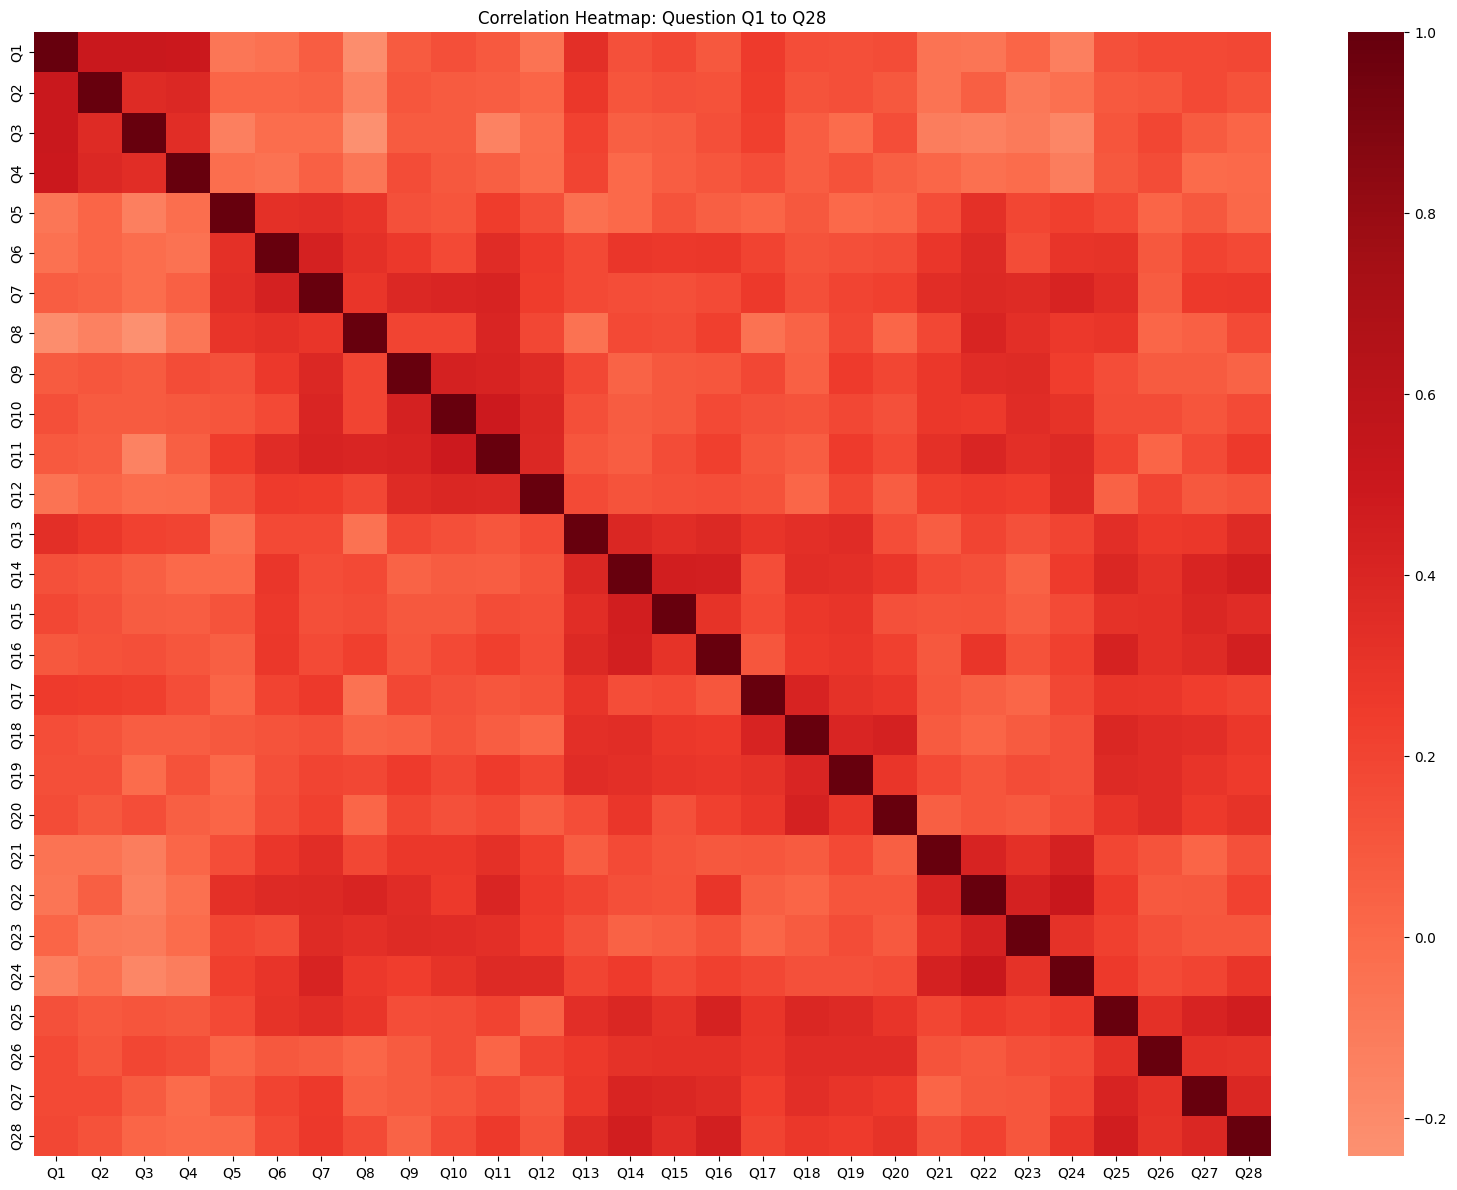

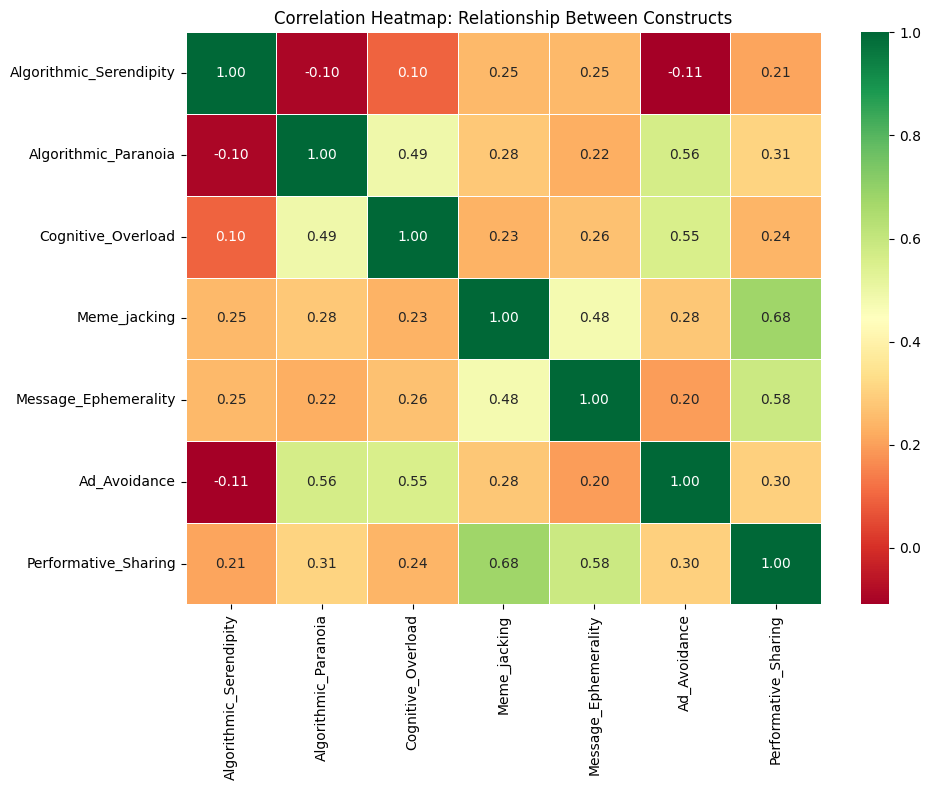

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# --- 1. LOAD DATA ---
file_path = 'Responses (4).xlsx'
df = pd.read_excel(file_path)

# --- 2. DEFINE CONSTRUCTS ---
constructs = {
    'Algorithmic_Serendipity': [
        'Algorithmic Serendipity (The pleasant surprise and relevance of ads) [I am often surprised by how well some ads match my interests.]',
        'Algorithmic Serendipity (The pleasant surprise and relevance of ads) [Advertisements sometimes introduce me to products I didn\'t know I needed.]',
        'Algorithmic Serendipity (The pleasant surprise and relevance of ads) [The timing of certain ads feels appropriate to my current needs or situation.]',
        'Algorithmic Serendipity (The pleasant surprise and relevance of ads) [Social media ads help me explore new products beyond what I usually search for.]'
    ],
    'Algorithmic_Paranoia': [
        'Algorithmic Paranoia (Concerns about privacy and control) [I feel uneasy when ads reflect things I have not explicitly searched for but are what I was looking for.]',
        'Algorithmic Paranoia (Concerns about privacy and control) [I question how my personal data is being used when I see highly relevant ads.]',
        'Algorithmic Paranoia (Concerns about privacy and control) [Personalized ads reduce my sense of control over my online experience.]',
        'Algorithmic Paranoia (Concerns about privacy and control) [I trust platforms less when their advertisements feel overly targeted.]'
    ],
    'Cognitive_Overload': [
        'Information Fatigue / Cognitive Overload (Difficulty processing ad content) [I find it difficult to focus on ads that change visuals or messages too quickly.]',
        'Information Fatigue / Cognitive Overload (Difficulty processing ad content) [I lose interest in ads that require too much effort to understand.]',
        'Information Fatigue / Cognitive Overload (Difficulty processing ad content) [Overly detailed advertisements make it harder for me to remember the main message.]',
        'Information Fatigue / Cognitive Overload (Difficulty processing ad content) [I prefer simple and clear ads over highly complex ones.]'
    ],
    'Meme_jacking': [
        'Meme-jacking (Use of viral trends and internet culture in ads) [I can easily recognize when an advertisement is based on a trending meme or format.]',
        'Meme-jacking (Use of viral trends and internet culture in ads) [Using viral trends in ads makes the brand feel more relatable to me.]',
        'Meme-jacking (Use of viral trends and internet culture in ads) [Some ads feel forced when brands try to imitate internet culture.]',
        'Meme-jacking (Use of viral trends and internet culture in ads) [Trend-based advertisements are more likely to grab my attention than traditional ads.]'
    ],
    'Message_Ephemerality': [
        'Message Ephemerality (Ads that disappear or are only available for a limited time) [I feel a sense of urgency when ads are available only for a limited time.]',
        'Message Ephemerality (Ads that disappear or are only available for a limited time) [Temporary ads are less memorable compared to permanent content.]',
        'Message Ephemerality (Ads that disappear or are only available for a limited time) [I am more likely to watch an ad fully if I know it will disappear soon.]',
        'Message Ephemerality (Ads that disappear or are only available for a limited time) [Short-lived ads feel less important than regular posts on my feed.]'
    ],
    'Ad_Avoidance': [
        'Ad-Avoidance Behaviour (Strategies to minimize exposure to ads) [I ignore ads even when they appear in the middle of content I am watching.]',
        'Ad-Avoidance Behaviour (Strategies to minimize exposure to ads) [I actively take steps (skip/block/report) to reduce ads on my feed.]',
        'Ad-Avoidance Behaviour (Strategies to minimize exposure to ads) [I tolerate ads only if they are relevant to my interests.]',
        'Ad-Avoidance Behaviour (Strategies to minimize exposure to ads) [I stop engaging with content when ads become too frequent.]'
    ],
    'Performative_Sharing': [
        'Performative Sharing (Sharing ads to signal identity or gain peer approval) [I am more likely to share advertisements that reflect values or causes I support.]',
        'Performative Sharing (Sharing ads to signal identity or gain peer approval) [I tend to share content that I believe will be appreciated by people in my social network.]',
        'Performative Sharing (Sharing ads to signal identity or gain peer approval) [Sharing certain advertisements helps me express what matters to me.]',
        'Performative Sharing (Sharing ads to signal identity or gain peer approval) [I am more likely to share ads that are currently popular or trending among my peers.]'
    ]
}

# --- 3. DATA CLEANING ---
all_likert_cols = [col for sublist in constructs.values() for col in sublist]

for col in all_likert_cols:
    df[col] = df[col].astype(str).str.extract(r'(\d+)').astype(float)

# --- 4. CALCULATE MEANS AND STANDARD DEVIATIONS ---
# Individual Question Stats
question_means = df[all_likert_cols].mean().round(2)
question_stds = df[all_likert_cols].std().round(2)

print("--- DESCRIPTIVE STATS PER QUESTION ---")
question_stats = pd.DataFrame({'Mean': question_means, 'Std Dev': question_stds})
print(question_stats)

# Construct Stats (Average of the 4 questions in each group)
for construct_name, cols in constructs.items():
    # Calculate the mean per participant for this construct
    df[construct_name] = df[cols].mean(axis=1)

construct_means = df[list(constructs.keys())].mean().round(2)
construct_stds = df[list(constructs.keys())].std().round(2)

print("\n--- DESCRIPTIVE STATS PER CONSTRUCT ---")
construct_stats = pd.DataFrame({'Mean': construct_means, 'Std Dev': construct_stds})
print(construct_stats)

# --- 5. CORRELATION PLOTTING ---

# Heatmap 1: Inter-Question Correlation
plt.figure(figsize=(16, 12))
short_labels = {col: f"Q{i+1}" for i, col in enumerate(all_likert_cols)}
df_for_corr = df[all_likert_cols].rename(columns=short_labels)

sns.heatmap(df_for_corr.corr(), annot=False, cmap='Reds', center=0)
plt.title("Correlation Heatmap: Question Q1 to Q28")
plt.tight_layout()
plt.show()

# Heatmap 2: Inter-Construct Correlation
plt.figure(figsize=(10, 8))
construct_corr = df[list(constructs.keys())].corr()

sns.heatmap(construct_corr, annot=True, cmap='RdYlGn', fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap: Relationship Between Constructs")
plt.tight_layout()
plt.show()

In [ ]:
pip install pandas numpy pingouin factor_analyzer openpyxl

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.8/42.8 kB 1.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.0/204.0 kB 4.6 MB/s eta 0:00:00
  Created wheel for factor_analyzer: filename=factor_analyzer-0.5.1-py2.py3-none-any.whl size=42655 sha256=96899f16408d438ed3b4cb1a47e7d714a5cff1d0bcd2fd668057c26f9fb37f7b
  Stored in directory: /root/.cache/pip/wheels/a2/af/06/f4d4ed4d9d714fda437fb1583629417319603c2266e7b233cc
Successfully built factor_analyzer


In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from factor_analyzer import FactorAnalyzer

# --- 1. LOAD AND CLEAN DATA ---
file_path = 'Responses (4).xlsx'
df = pd.read_excel(file_path)

# Map the exact Google Forms headers to their constructs
constructs = {
    'Algorithmic_Serendipity': [
        'Algorithmic Serendipity (The pleasant surprise and relevance of ads) [I am often surprised by how well some ads match my interests.]',
        'Algorithmic Serendipity (The pleasant surprise and relevance of ads) [Advertisements sometimes introduce me to products I didn\'t know I needed.]',
        'Algorithmic Serendipity (The pleasant surprise and relevance of ads) [The timing of certain ads feels appropriate to my current needs or situation.]',
        'Algorithmic Serendipity (The pleasant surprise and relevance of ads) [Social media ads help me explore new products beyond what I usually search for.]'
    ],
    'Algorithmic_Paranoia': [
        'Algorithmic Paranoia (Concerns about privacy and control) [I feel uneasy when ads reflect things I have not explicitly searched for but are what I was looking for.]',
        'Algorithmic Paranoia (Concerns about privacy and control) [I question how my personal data is being used when I see highly relevant ads.]',
        'Algorithmic Paranoia (Concerns about privacy and control) [Personalized ads reduce my sense of control over my online experience.]',
        'Algorithmic Paranoia (Concerns about privacy and control) [I trust platforms less when their advertisements feel overly targeted.]'
    ],
    'Cognitive_Overload': [
        'Information Fatigue / Cognitive Overload (Difficulty processing ad content) [I find it difficult to focus on ads that change visuals or messages too quickly.]',
        'Information Fatigue / Cognitive Overload (Difficulty processing ad content) [I lose interest in ads that require too much effort to understand.]',
        'Information Fatigue / Cognitive Overload (Difficulty processing ad content) [Overly detailed advertisements make it harder for me to remember the main message.]',
        'Information Fatigue / Cognitive Overload (Difficulty processing ad content) [I prefer simple and clear ads over highly complex ones.]'
    ],
    'Meme_jacking': [
        'Meme-jacking (Use of viral trends and internet culture in ads) [I can easily recognize when an advertisement is based on a trending meme or format.]',
        'Meme-jacking (Use of viral trends and internet culture in ads) [Using viral trends in ads makes the brand feel more relatable to me.]',
        'Meme-jacking (Use of viral trends and internet culture in ads) [Some ads feel forced when brands try to imitate internet culture.]',
        'Meme-jacking (Use of viral trends and internet culture in ads) [Trend-based advertisements are more likely to grab my attention than traditional ads.]'
    ],
    'Message_Ephemerality': [
        'Message Ephemerality (Ads that disappear or are only available for a limited time) [I feel a sense of urgency when ads are available only for a limited time.]',
        'Message Ephemerality (Ads that disappear or are only available for a limited time) [Temporary ads are less memorable compared to permanent content.]',
        'Message Ephemerality (Ads that disappear or are only available for a limited time) [I am more likely to watch an ad fully if I know it will disappear soon.]',
        'Message Ephemerality (Ads that disappear or are only available for a limited time) [Short-lived ads feel less important than regular posts on my feed.]'
    ],
    'Ad_Avoidance': [
        'Ad-Avoidance Behaviour (Strategies to minimize exposure to ads) [I ignore ads even when they appear in the middle of content I am watching.]',
        'Ad-Avoidance Behaviour (Strategies to minimize exposure to ads) [I actively take steps (skip/block/report) to reduce ads on my feed.]',
        'Ad-Avoidance Behaviour (Strategies to minimize exposure to ads) [I tolerate ads only if they are relevant to my interests.]',
        'Ad-Avoidance Behaviour (Strategies to minimize exposure to ads) [I stop engaging with content when ads become too frequent.]'
    ],
    'Performative_Sharing': [
        'Performative Sharing (Sharing ads to signal identity or gain peer approval) [I am more likely to share advertisements that reflect values or causes I support.]',
        'Performative Sharing (Sharing ads to signal identity or gain peer approval) [I tend to share content that I believe will be appreciated by people in my social network.]',
        'Performative Sharing (Sharing ads to signal identity or gain peer approval) [Sharing certain advertisements helps me express what matters to me.]',
        'Performative Sharing (Sharing ads to signal identity or gain peer approval) [I am more likely to share ads that are currently popular or trending among my peers.]'
    ]
}

# Clean data: Extract digits and drop blanks
all_cols = [col for sublist in constructs.values() for col in sublist]
for col in all_cols:
    df[col] = df[col].astype(str).str.extract(r'(\d+)').astype(float)
df = df.dropna(subset=all_cols)

print("======================================================")
print("     OUTER MODEL: INDICATOR RELIABILITY & COLLINEARITY")
print("======================================================\n")

# Store results for a clean summary table
all_results = []

for construct_name, items in constructs.items():
    subset = df[items]

    # --- A. Indicator Reliability (Outer Loadings) ---
    # We use a 1-factor model to see how strongly each question ties to the construct
    fa = FactorAnalyzer(n_factors=1, rotation=None)
    fa.fit(subset)
    loadings = fa.loadings_.flatten()

    # --- B. Outer Collinearity (VIF) ---
    # We add a constant to calculate VIF correctly for standard Likert data
    X_vif = sm.add_constant(subset)

    # Calculate VIF for each question (ignoring the constant at index 0)
    vifs = [variance_inflation_factor(X_vif.values, i) for i in range(1, X_vif.shape[1])]

    # --- Assemble the results ---
    for i, item in enumerate(items):
        # Shorten the question text for a cleaner display
        short_q = item.split('[')[1][:40] + "...]" if '[' in item else item[:40]

        # Evaluate against standard PLS-SEM thresholds
        loading_status = "Pass" if loadings[i] >= 0.708 else "Warning (Low)"
        vif_status = "Pass" if vifs[i] <= 3.3 else "Warning (High)"

        all_results.append({
            'Construct': construct_name,
            'Indicator': short_q,
            'Outer Loading': round(loadings[i], 3),
            'Loading Status': loading_status,
            'VIF': round(vifs[i], 3),
            'VIF Status': vif_status
        })

# --- Print Final Summary Table ---
results_df = pd.DataFrame(all_results)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

print(results_df.to_string(index=False))

print("\n--- THRESHOLD GUIDE ---")
print("1. Indicator Reliability (Outer Loadings): Should be > 0.708.")
print("   *Meaning:* The question strongly reflects the core construct. If < 0.40, consider removing the question.")
print("2. Outer Collinearity (VIF): Should be < 3.3 (up to 5.0 is acceptable in some contexts).")
print("   *Meaning:* If VIF is too high, the question is practically identical to another question in that same group, causing redundant data.")

     OUTER MODEL: INDICATOR RELIABILITY & COLLINEARITY



/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12

              Construct                                    Indicator  Outer Loading Loading Status   VIF VIF Status
Algorithmic_Serendipity I am often surprised by how well some ad...]         -0.833  Warning (Low) 1.788       Pass
Algorithmic_Serendipity Advertisements sometimes introduce me to...]         -0.617  Warning (Low) 1.411       Pass
Algorithmic_Serendipity The timing of certain ads feels appropri...]         -0.600  Warning (Low) 1.396       Pass
Algorithmic_Serendipity Social media ads help me explore new pro...]         -0.599  Warning (Low) 1.386       Pass
   Algorithmic_Paranoia I feel uneasy when ads reflect things I ...]         -0.541  Warning (Low) 1.229       Pass
   Algorithmic_Paranoia I question how my personal data is being...]         -0.650  Warning (Low) 1.340       Pass
   Algorithmic_Paranoia Personalized ads reduce my sense of cont...]         -0.637  Warning (Low) 1.330       Pass
   Algorithmic_Paranoia I trust platforms less when their advert...]    

In [ ]:
pip install pandas numpy statsmodels matplotlib seaborn openpyxl

     INNER MODEL: STRUCTURAL & HYPOTHESIS TESTING     

------------------------------------------------------
   MODEL 1: PREDICTING AD-AVOIDANCE
------------------------------------------------------
Explanatory Power (R-squared): 0.434
(This means 43.4% of the variance in Ad-Avoidance is explained by this model)

                 Hypothesis / Path   Beta  P-Value               Result
                       (Intercept)  1.437    0.000                    -
    H1a: Paranoia -> Avoidance (+)  0.421    0.000            Supported
     H1a: Fatigue -> Avoidance (+)  0.369    0.000            Supported
 H1b: Serendipity -> Avoidance (-) -0.117    0.087 Rejected (p >= 0.05)
H2b: Ephemerality -> Avoidance (-)  0.047    0.542 Rejected (p >= 0.05)
H1c: Moderation (Para x Seren) (-)  0.034    0.708 Rejected (p >= 0.05)


------------------------------------------------------
   MODEL 2: PREDICTING PERFORMATIVE SHARING
------------------------------------------------------
Explanatory Power (R-s

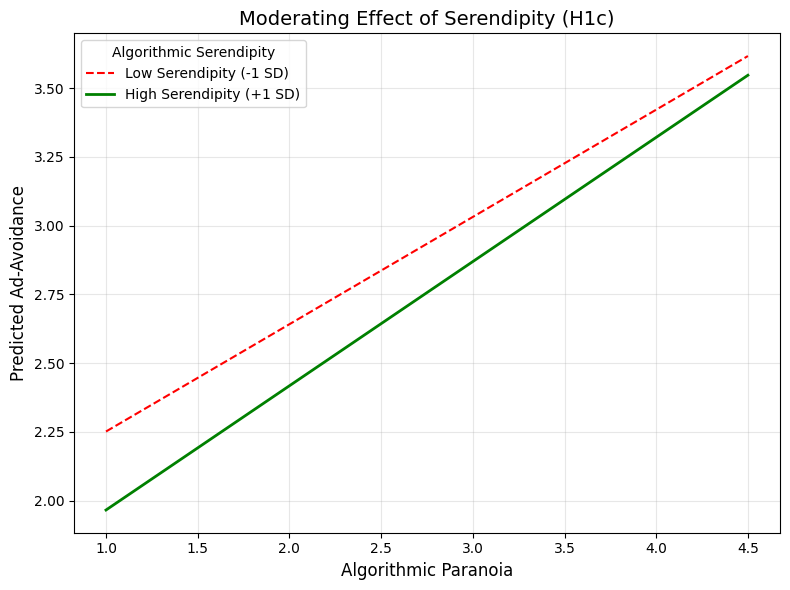

-> A Simple Slopes graph has been generated in a new window.
-> Interpretation: If H1c is supported, the Red dashed line (Low Serendipity) should be STEEPER than the Green solid line (High Serendipity). This visually proves that high serendipity 'buffers' or weakens the effect of paranoia on avoidance.


In [ ]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. LOAD AND CLEAN DATA ---
file_path = 'Responses (4).xlsx'
df = pd.read_excel(file_path)

# Dictionary of your exact Google Form headers
constructs = {
    'Serendipity': [
        'Algorithmic Serendipity (The pleasant surprise and relevance of ads) [I am often surprised by how well some ads match my interests.]',
        'Algorithmic Serendipity (The pleasant surprise and relevance of ads) [Advertisements sometimes introduce me to products I didn\'t know I needed.]',
        'Algorithmic Serendipity (The pleasant surprise and relevance of ads) [The timing of certain ads feels appropriate to my current needs or situation.]',
        'Algorithmic Serendipity (The pleasant surprise and relevance of ads) [Social media ads help me explore new products beyond what I usually search for.]'
    ],
    'Paranoia': [
        'Algorithmic Paranoia (Concerns about privacy and control) [I feel uneasy when ads reflect things I have not explicitly searched for but are what I was looking for.]',
        'Algorithmic Paranoia (Concerns about privacy and control) [I question how my personal data is being used when I see highly relevant ads.]',
        'Algorithmic Paranoia (Concerns about privacy and control) [Personalized ads reduce my sense of control over my online experience.]',
        'Algorithmic Paranoia (Concerns about privacy and control) [I trust platforms less when their advertisements feel overly targeted.]'
    ],
    'Fatigue': [
        'Information Fatigue / Cognitive Overload (Difficulty processing ad content) [I find it difficult to focus on ads that change visuals or messages too quickly.]',
        'Information Fatigue / Cognitive Overload (Difficulty processing ad content) [I lose interest in ads that require too much effort to understand.]',
        'Information Fatigue / Cognitive Overload (Difficulty processing ad content) [Overly detailed advertisements make it harder for me to remember the main message.]',
        'Information Fatigue / Cognitive Overload (Difficulty processing ad content) [I prefer simple and clear ads over highly complex ones.]'
    ],
    'Meme_jacking': [
        'Meme-jacking (Use of viral trends and internet culture in ads) [I can easily recognize when an advertisement is based on a trending meme or format.]',
        'Meme-jacking (Use of viral trends and internet culture in ads) [Using viral trends in ads makes the brand feel more relatable to me.]',
        'Meme-jacking (Use of viral trends and internet culture in ads) [Some ads feel forced when brands try to imitate internet culture.]',
        'Meme-jacking (Use of viral trends and internet culture in ads) [Trend-based advertisements are more likely to grab my attention than traditional ads.]'
    ],
    'Ephemerality': [
        'Message Ephemerality (Ads that disappear or are only available for a limited time) [I feel a sense of urgency when ads are available only for a limited time.]',
        'Message Ephemerality (Ads that disappear or are only available for a limited time) [Temporary ads are less memorable compared to permanent content.]',
        'Message Ephemerality (Ads that disappear or are only available for a limited time) [I am more likely to watch an ad fully if I know it will disappear soon.]',
        'Message Ephemerality (Ads that disappear or are only available for a limited time) [Short-lived ads feel less important than regular posts on my feed.]'
    ],
    'Avoidance': [
        'Ad-Avoidance Behaviour (Strategies to minimize exposure to ads) [I ignore ads even when they appear in the middle of content I am watching.]',
        'Ad-Avoidance Behaviour (Strategies to minimize exposure to ads) [I actively take steps (skip/block/report) to reduce ads on my feed.]',
        'Ad-Avoidance Behaviour (Strategies to minimize exposure to ads) [I tolerate ads only if they are relevant to my interests.]',
        'Ad-Avoidance Behaviour (Strategies to minimize exposure to ads) [I stop engaging with content when ads become too frequent.]'
    ],
    'Sharing': [
        'Performative Sharing (Sharing ads to signal identity or gain peer approval) [I am more likely to share advertisements that reflect values or causes I support.]',
        'Performative Sharing (Sharing ads to signal identity or gain peer approval) [I tend to share content that I believe will be appreciated by people in my social network.]',
        'Performative Sharing (Sharing ads to signal identity or gain peer approval) [Sharing certain advertisements helps me express what matters to me.]',
        'Performative Sharing (Sharing ads to signal identity or gain peer approval) [I am more likely to share ads that are currently popular or trending among my peers.]'
    ]
}

# Clean data: Extract digits and drop blanks
all_cols = [col for sublist in constructs.values() for col in sublist]
for col in all_cols:
    df[col] = df[col].astype(str).str.extract(r'(\d+)').astype(float)
df = df.dropna(subset=all_cols)

# Create Composite Scores (Mode A: Mean of indicators)
for key, cols in constructs.items():
    df[key] = df[cols].mean(axis=1)

print("======================================================")
print("     INNER MODEL: STRUCTURAL & HYPOTHESIS TESTING     ")
print("======================================================\n")

# --- 2. PREPARE FOR MODERATION (Mean Centering) ---
# Mean centering is statistically required before creating interaction terms
df['Paranoia_C'] = df['Paranoia'] - df['Paranoia'].mean()
df['Serendipity_C'] = df['Serendipity'] - df['Serendipity'].mean()
df['Interaction_H1c'] = df['Paranoia_C'] * df['Serendipity_C']


# --- 3. MODEL 1: AD-AVOIDANCE (H1a, H1b, H1c, H2b) ---
print("------------------------------------------------------")
print("   MODEL 1: PREDICTING AD-AVOIDANCE")
print("------------------------------------------------------")
# Fit regression using robust standard errors (HC3), standard for PLS-SEM approximations
model1 = smf.ols('Avoidance ~ Paranoia_C + Fatigue + Serendipity_C + Ephemerality + Interaction_H1c', data=df).fit(cov_type='HC3')

print(f"Explanatory Power (R-squared): {model1.rsquared:.3f}")
print(f"(This means {model1.rsquared * 100:.1f}% of the variance in Ad-Avoidance is explained by this model)\n")

# Format Results
res1 = pd.DataFrame({
    'Hypothesis / Path': [
        '(Intercept)',
        'H1a: Paranoia -> Avoidance (+)',
        'H1a: Fatigue -> Avoidance (+)',
        'H1b: Serendipity -> Avoidance (-)',
        'H2b: Ephemerality -> Avoidance (-)',
        'H1c: Moderation (Para x Seren) (-)'
    ],
    'Beta': model1.params.values,
    'P-Value': model1.pvalues.values
})

# Determine if supported based on p < 0.05 AND correct direction (Beta +/-)
def check_support(row):
    if 'Intercept' in row['Hypothesis / Path']: return "-"
    if row['P-Value'] >= 0.05: return "Rejected (p >= 0.05)"

    # Check directions
    if '(+)' in row['Hypothesis / Path'] and row['Beta'] > 0: return "Supported"
    if '(-)' in row['Hypothesis / Path'] and row['Beta'] < 0: return "Supported"
    return "Rejected (Wrong Direction)"

res1['Result'] = res1.apply(check_support, axis=1)
print(res1.round(3).to_string(index=False))
print("\n")


# --- 4. MODEL 2: PERFORMATIVE SHARING (H2a, H2c) ---
print("------------------------------------------------------")
print("   MODEL 2: PREDICTING PERFORMATIVE SHARING")
print("------------------------------------------------------")
model2 = smf.ols('Sharing ~ Meme_jacking + Ephemerality', data=df).fit(cov_type='HC3')

print(f"Explanatory Power (R-squared): {model2.rsquared:.3f}")
print(f"(This means {model2.rsquared * 100:.1f}% of Performative Sharing is explained by this model)\n")

res2 = pd.DataFrame({
    'Hypothesis / Path': [
        '(Intercept)',
        'H2a/H2c: Meme-jacking -> Sharing (+)',
        'H2b: Ephemerality -> Sharing (+)'
    ],
    'Beta': model2.params.values,
    'P-Value': model2.pvalues.values
})
res2['Result'] = res2.apply(check_support, axis=1)
print(res2.round(3).to_string(index=False))
print("\n")


# --- 5. ADVANCED ANALYSIS: SIMPLE SLOPES PLOT (For H1c) ---
print("======================================================")
print("     GENERATING MODERATION PLOT (SIMPLE SLOPES)       ")
print("======================================================")
# We only plot this if the interaction is meaningful, but it's generated here for your paper.
# We look at the effect of Paranoia on Avoidance at LOW (-1 SD) and HIGH (+1 SD) Serendipity.

sd_seren = df['Serendipity_C'].std()
mean_fatigue = df['Fatigue'].mean()
mean_ephem = df['Ephemerality'].mean()

# Define the X-axis (Low to High Paranoia)
paranoia_range = np.linspace(df['Paranoia_C'].min(), df['Paranoia_C'].max(), 100)

# Calculate predicted Avoidance for Low Serendipity (-1 SD)
y_low_seren = (model1.params['Intercept'] +
               model1.params['Paranoia_C'] * paranoia_range +
               model1.params['Fatigue'] * mean_fatigue +
               model1.params['Serendipity_C'] * (-sd_seren) +
               model1.params['Ephemerality'] * mean_ephem +
               model1.params['Interaction_H1c'] * (paranoia_range * -sd_seren))

# Calculate predicted Avoidance for High Serendipity (+1 SD)
y_high_seren = (model1.params['Intercept'] +
                model1.params['Paranoia_C'] * paranoia_range +
                model1.params['Fatigue'] * mean_fatigue +
                model1.params['Serendipity_C'] * (sd_seren) +
                model1.params['Ephemerality'] * mean_ephem +
                model1.params['Interaction_H1c'] * (paranoia_range * sd_seren))

# Plotting
plt.figure(figsize=(8, 6))
plt.plot(paranoia_range + df['Paranoia'].mean(), y_low_seren, label='Low Serendipity (-1 SD)', color='red', linestyle='--')
plt.plot(paranoia_range + df['Paranoia'].mean(), y_high_seren, label='High Serendipity (+1 SD)', color='green', linewidth=2)

plt.title('Moderating Effect of Serendipity (H1c)', fontsize=14)
plt.xlabel('Algorithmic Paranoia', fontsize=12)
plt.ylabel('Predicted Ad-Avoidance', fontsize=12)
plt.legend(title='Algorithmic Serendipity')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("-> A Simple Slopes graph has been generated in a new window.")
print("-> Interpretation: If H1c is supported, the Red dashed line (Low Serendipity) should be STEEPER than the Green solid line (High Serendipity). This visually proves that high serendipity 'buffers' or weakens the effect of paranoia on avoidance.")